# Autoencoder Tutorial

[Autoencoder In PyTorch - Theory & Implementation](https://www.youtube.com/watch?v=zp8clK9yCro)
by Patrick Loeber

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms

In [9]:
transform = transforms.ToTensor()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#mnist_data = datasets.MNIST(root='./datasets', train=True, download=True, transform=transform)

data_loader = torch.utils.data.DataLoader(mnist_data, 
                                          batch_size=64,
                                          shuffle=True)

In [10]:
dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


In [ ]:
class Autoencoder_Linear(nn.Module):
    def __init__(self):
        # N, 784
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128), # N, 784 -> N, 128
            nn.ReLU(),
            nn.Linear(128, 64), # N, 128 -> N, 64
            nn.ReLU(),
            nn.Linear(64, 12), # N, 64 -> N, 12
            nn.ReLU(),
            nn.Linear(12, 3) # N, 12 -> N, 3
        )

        self.decoder = nn.Sequential(
            nn.Linear(3, 12), # N, 3 -> N, 12
            nn.ReLU(),
            nn.Linear(12, 64), # N, 12 -> N, 64
            nn.ReLU(),
            nn.Linear(64, 128), # N, 64 -> N, 128
            nn.ReLU(),
            nn.Linear(128, 28*28), # N, 128 -> N, 784
            nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
# Note: [-1, 1] -> tanh

In [ ]:
model = Autoencoder_Linear()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=1e-3, 
                             weight_decay=1e-5)

In [ ]:
num_epochs = 5
outputs = []
for epoch in range(num_epochs):
    for (img, _) in data_loader:
        img = img.reshape(-1, 28*28) # # -> use for Autoencoder_Linear
        recon = model(img)
        loss = criterion(recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f'Epoch: {epoch+1}, Loss: {loss.item():.4f}')
    outputs.append((epoch, img, recon))

Epoch: 1, Loss: 0.0380
Epoch: 2, Loss: 0.0398
Epoch: 3, Loss: 0.0391
Epoch: 4, Loss: 0.0370
Epoch: 5, Loss: 0.0344


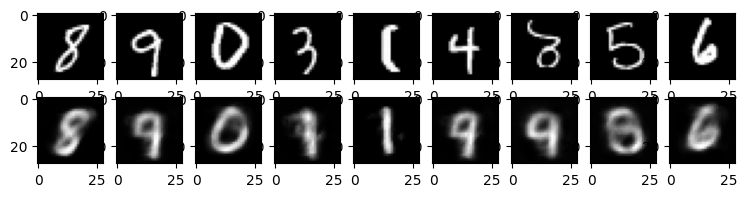

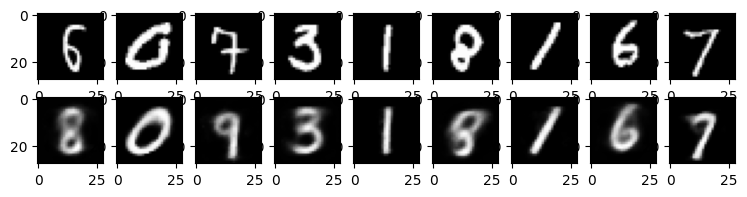

In [ ]:
for k in range(0, num_epochs, 4):
    plt.figure(figsize=(9, 2))
    plt.gray()
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9: break
        plt.subplot(2, 9, i+1)
        item = item.reshape(-1, 28,28) # -> use for Autoencoder_Linear
        
        plt.imshow(item[0]) # item: 1, 28, 28

    for i, item in enumerate(recon):
        if i >= 9: break
        plt.subplot(2, 9, 9+i+1) # row_length + i + 1
        item = item.reshape(-1, 28,28) # -> use for Autoencoder_Linear
        
        plt.imshow(item[0]) # item: 1, 28, 28

In [22]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()        
        # N, 1, 28, 28
        self.encoder = nn.Sequential(
            # (input_channel, output_channel, kernel_size, stride, padding)
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # N, 1, 28, 28 -> N, 16, 14, 14 (REDUCE BY HALF)
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # -> N, 32, 7, 7
            nn.ReLU(),
            nn.Conv2d(32, 64, 7) # -> N, 64, 1, 1
        )
        
        # N , 64, 1, 1
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7), # -> N, 32, 7, 7
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # N, 16, 14, 14 (N,16,13,13 without output_padding)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), # N, 1, 28, 28  (N,1,27,27)
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
 
# Note: nn.MaxPool2d -> use nn.MaxUnpool2d, or use different kernelsize, stride etc to compensate...
# Input [-1, +1] -> use nn.Tanh

In [23]:
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=1e-3, 
                             weight_decay=1e-5)

In [24]:
num_epochs = 5
outputs = []
for epoch in range(num_epochs):
    for (img, _) in data_loader:
        #img = img.reshape(-1, 28*28) # # -> use for Autoencoder_Linear
        recon = model(img)
        loss = criterion(recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f'Epoch: {epoch+1}, Loss: {loss.item():.4f}')
    outputs.append((epoch, img, recon))

Epoch: 1, Loss: 0.0105
Epoch: 2, Loss: 0.0064
Epoch: 3, Loss: 0.0049
Epoch: 4, Loss: 0.0043
Epoch: 5, Loss: 0.0037


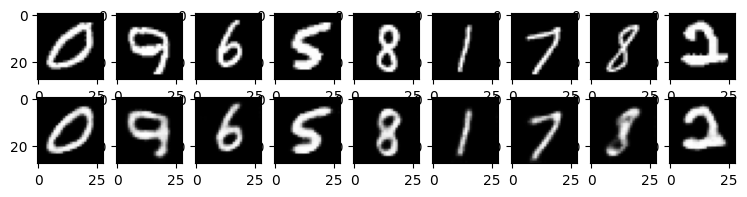

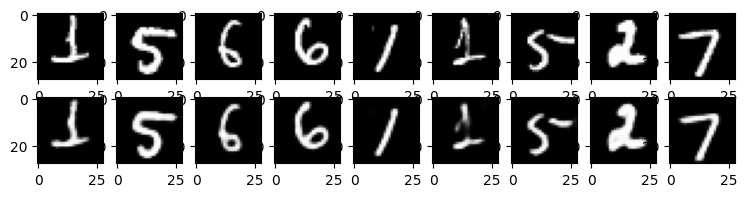

In [25]:
for k in range(0, num_epochs, 4):
    plt.figure(figsize=(9, 2))
    plt.gray()
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9: break
        plt.subplot(2, 9, i+1)
        #item = item.reshape(-1, 28,28) # -> use for Autoencoder_Linear
        
        plt.imshow(item[0]) # item: 1, 28, 28

    for i, item in enumerate(recon):
        if i >= 9: break
        plt.subplot(2, 9, 9+i+1) # row_length + i + 1
        #item = item.reshape(-1, 28,28) # -> use for Autoencoder_Linear
        
        plt.imshow(item[0]) # item: 1, 28, 28